# **Evaluation Notebook**

### **Wikiart Project**

**Group x:**\
**Afonso Hermenegildo** - 202 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951 | **André Nicolau** - 2022

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

1. [Classification report (accuracy, macro-F1, per-class precision/recall)](#section-1)  
2. [Confusion matrix (seaborn heatmap)](#section-2)  
3. [Training curves (loss & accuracy)](#section-3)  
4. [Grad-CAM visualisation](#section-4)  
5. [Misclassified samples analysis](#section-5)
6. [Model comparison table](#section-5)

---

# Imports

In [1]:
import sys
from pathlib import Path

# Make project-level modules importable (src/ contains augmentation.py)
_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

import keras
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import image_dataset_from_directory
from Base_Model_Class import BatchNormalization2_Model


In [2]:
# Project paths
PROJECT_ROOT = _PROJECT_ROOT
MODULES_DIR = PROJECT_ROOT
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load dataset

In [3]:
Train_Path = "Data/Train"
Validation_Path = "Data/Validation"
Test_Path = "Data/Test"

Input_shape = (128,128,3) 
Batch_size = 64

In [4]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[]

In [5]:
train_df = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (128,128),
    batch_size=Batch_size,
    seed=42
)

Found 9329 files belonging to 23 classes.


In [6]:
train_df = image_dataset_from_directory(
    Train_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (128,128),
    batch_size=Batch_size,
    seed=42
)

val_df = image_dataset_from_directory(
    Validation_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (128,128),
    batch_size=Batch_size,
    seed=42
)

test_df = image_dataset_from_directory(
    Test_Path,
    label_mode="categorical",
    interpolation="bilinear",
    image_size= (128,128),
    batch_size=Batch_size,
    seed=42
)

class_names = train_df.class_names
print(f"Classes: {len(class_names)} — {class_names}")

Found 9329 files belonging to 23 classes.


Found 1999 files belonging to 23 classes.


Found 2000 files belonging to 23 classes.


Classes: 23 — ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


Because we've done our one subclassed model, model.build() often fails to statically infer shapes through complex internal layers like data augmentation. 
By running a dummy image through the network instead, we force a real forward pass that guarantees every layer dynamically initializes its weights based on the actual tensor size.

In [7]:
# Load the best checkpoint saved during training
# Update the path to match whichever model you want to evaluate
model = BatchNormalization2_Model()
model.build((None, 128, 128, 3))

# 2. Create a "dummy" image (Batch size 1, 128x128 pixels, 3 color channels)
# We fill it with zeros so it processes instantly
dummy_image = tf.zeros((1, 128, 128, 3))

# 3. FORCE the model to build by doing a quick prediction
# We don't care about the output, we just need the data to flow through
_ = model(dummy_image)

model_path = PROJECT_ROOT / "Base_Model.keras"
model = keras.models.load_model(model_path)

print(f'Model loaded from: {model_path}')
model.summary()

Model loaded from: /Users/andreferreira/dev/NOVAIMS/DeepLearning/Project3_oficial/Base_Model.keras


/Users/andreferreira/dev/NOVAIMS/DeepLearning/Project3_oficial/.venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'BatchNormalization_Model2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "BatchNormalization_Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_moderate           │ ?                      │             0 │
│ (Pipeline)                      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 124, 124, 40)   │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 124, 124, 40)   │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_1 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 62, 62, 40)     │        14,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 62, 62, 40)     │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_2 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_3 (Conv2D)           │ (None, 31, 31, 64)     │        23,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 31, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_3 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_4 (Conv2D)           │ (None, 15, 15, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_layer_4 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,32

 Total params: 254,911 (995.75 KB)

 Trainable params: 84,831 (331.37 KB)

 Non-trainable params: 416 (1.62 KB)

 Optimizer params: 169,664 (662.75 KB)

# Make Predictions

In [8]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_df:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

accuracy = np.mean(y_true == y_pred)
print(f'Test accuracy: {accuracy:.4f}')

Test accuracy: 0.5110


# Classification Report

## 4. Classification report
> Primary metric for this project is **macro-F1** because classes may be imbalanced.
> Macro-F1 gives equal weight to all classes regardless of size.
> If macro-F1 is much lower than accuracy, the model is biased toward majority classes.

In [9]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save as file for the report
with open(OUTPUTS_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)
print('Saved!')

                       precision    recall  f1-score   support

       Albrecht_Durer       0.59      0.45      0.51        87
      Boris_Kustodiev       0.44      0.30      0.36        67
     Camille_Pissarro       0.39      0.40      0.39        93
        Childe_Hassam       0.48      0.18      0.26        57
         Claude_Monet       0.48      0.70      0.57       140
          Edgar_Degas       0.42      0.28      0.34        64
        Eugene_Boudin       0.63      0.47      0.53        58
         Gustave_Dore       0.75      0.89      0.81        80
           Ilya_Repin       0.43      0.39      0.41        56
      Ivan_Aivazovsky       0.84      0.63      0.72        60
        Ivan_Shishkin       0.52      0.48      0.50        54
  John_Singer_Sargent       0.50      0.36      0.42        83
         Marc_Chagall       0.35      0.23      0.28        81
      Martiros_Saryan       0.28      0.28      0.28        61
     Nicholas_Roerich       0.60      0.69      0.64  

## 5. Confusion matrix
> The diagonal = correct predictions. Off-diagonal = errors.
> Look for clusters of errors between visually similar classes.

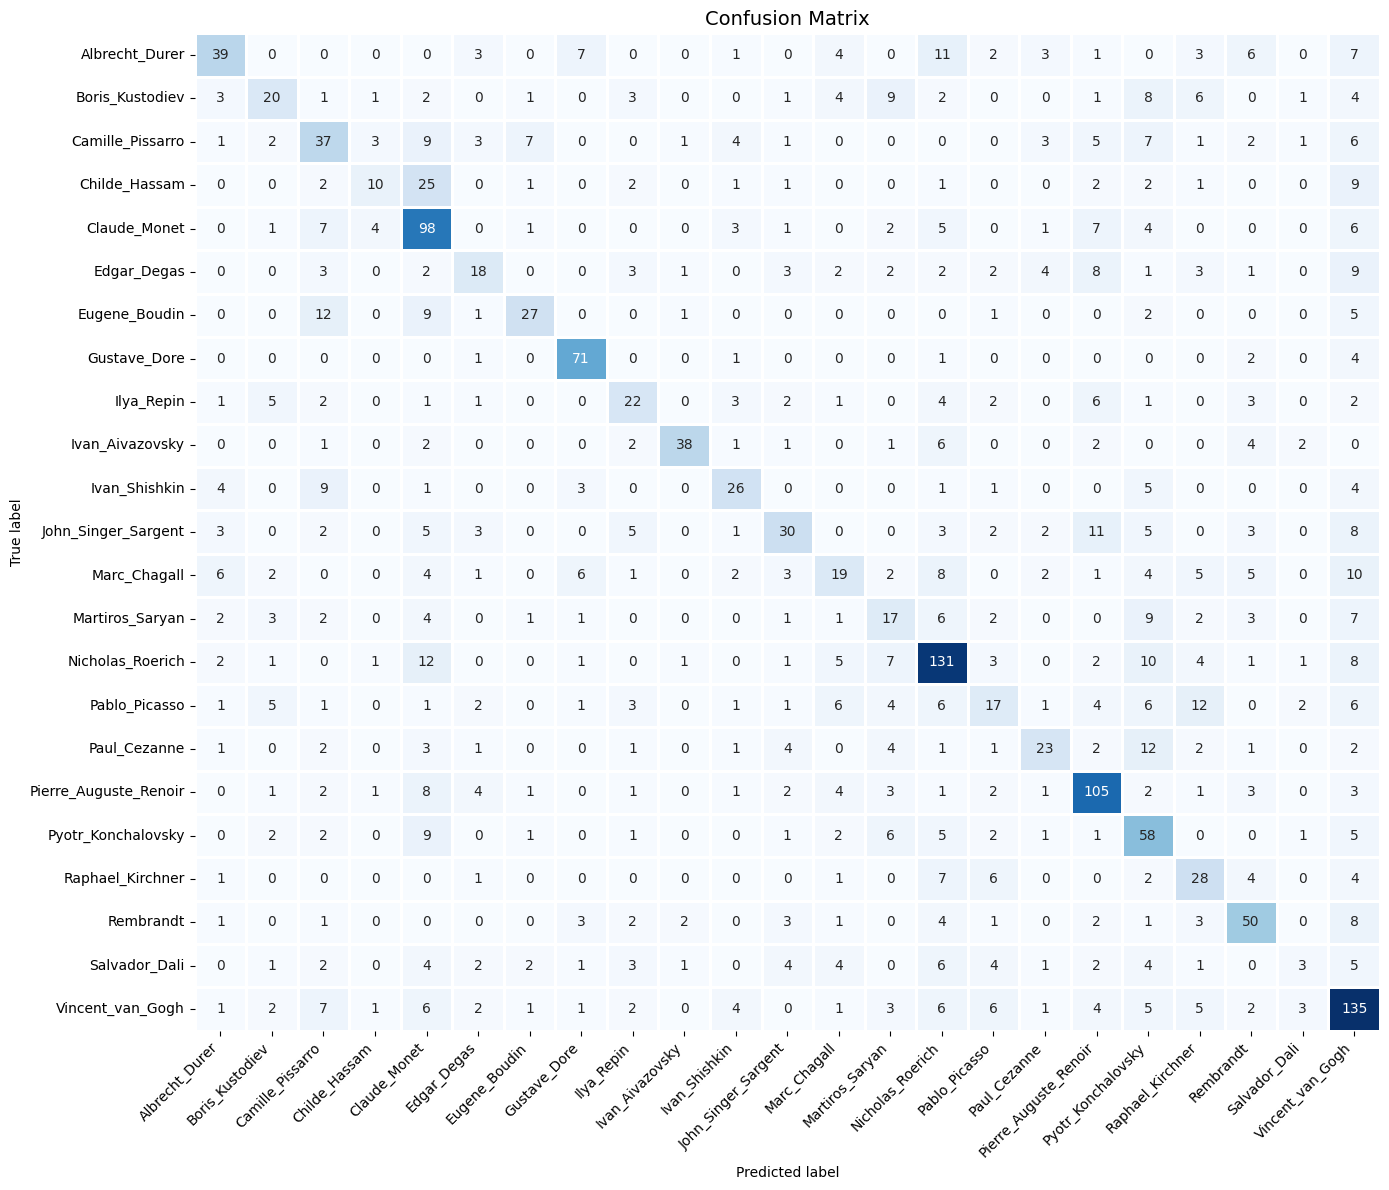


Per-class accuracy:
  Albrecht_Durer                 0.448
  Boris_Kustodiev                0.299
  Camille_Pissarro               0.398
  Childe_Hassam                  0.175
  Claude_Monet                   0.700
  Edgar_Degas                    0.281
  Eugene_Boudin                  0.466
  Gustave_Dore                   0.887
  Ilya_Repin                     0.393
  Ivan_Aivazovsky                0.633
  Ivan_Shishkin                  0.481
  John_Singer_Sargent            0.361
  Marc_Chagall                   0.235
  Martiros_Saryan                0.279
  Nicholas_Roerich               0.686
  Pablo_Picasso                  0.212
  Paul_Cezanne                   0.377
  Pierre_Auguste_Renoir          0.719
  Pyotr_Konchalovsky             0.598
  Raphael_Kirchner               0.519
  Rembrandt                      0.610
  Salvador_Dali                  0.060
  Vincent_van_Gogh               0.682


In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=1,
    cbar=False,
    annot_kws={'fontsize': 10},
    yticklabels=class_names,
    xticklabels=class_names,
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save figure for the report
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    per_class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {name:<30} {per_class_acc:.3f}')

## 7. Grad-CAM
> Visualises which regions of the painting the model focuses on.
> Reference: https://keras.io/examples/vision/grad_cam/
> For VGG16, the last conv layer is `block5_conv3`.

In [11]:
inp = keras.Input(shape=(128, 128, 3))
x = model.Rescaling(inp)
x = model.augmentation_layer(x)

x = model.Conv1(x)
x = model.BatchNormalization_layer1(x)
x = model.activation_1(x)
x = model.max_pool_layer_1(x)

x = model.Conv2(x)
x = model.BatchNormalization_layer2(x)
x = model.activation_2(x)
x = model.max_pool_layer_2(x)

x = model.Conv3(x)
x = model.BatchNormalization_layer3(x)
x = model.activation_3(x)
x = model.max_pool_layer_3(x)

x = model.Conv4(x)
x = model.BatchNormalization_layer4(x)
conv_out = model.activation_4(x)  # last conv activation = Grad-CAM tap point
x = model.max_pool_layer_4(conv_out)
x = model.Globalaveragepooling_layer(x)
x = model.Dense_1(x)
x = model.Drop_out(x)
out = model.Dense_2(x)

grad_model = keras.Model(inputs=inp, outputs=[conv_out, out])

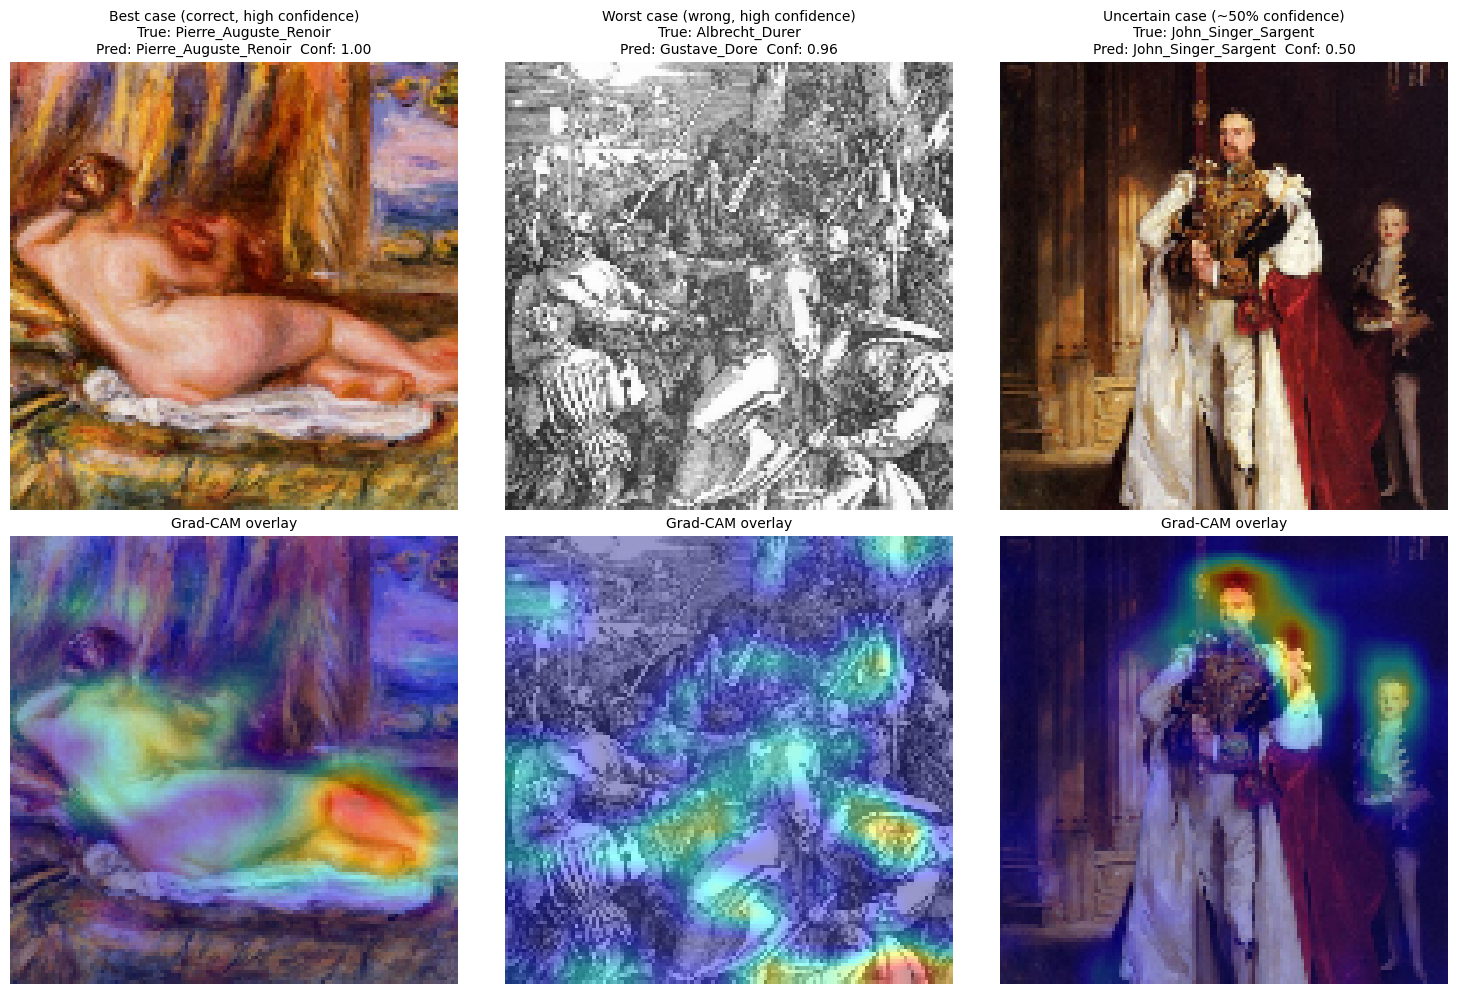

In [12]:
# Collect all test images with predictions and confidences in one pass
# (self-contained so we don't rely on ordering from earlier prediction loops)
all_images_list, all_true_list, all_pred_list, all_conf_list = [], [], [], []

for images, labels in test_df:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = np.argmax(labels.numpy(), axis=1)
    confs = probs[np.arange(len(preds)), preds]

    all_images_list.append(images.numpy())
    all_true_list.append(trues)
    all_pred_list.append(preds)
    all_conf_list.append(confs)

all_images = np.concatenate(all_images_list, axis=0)
all_true = np.concatenate(all_true_list, axis=0)
all_pred = np.concatenate(all_pred_list, axis=0)
all_conf = np.concatenate(all_conf_list, axis=0)

# 1. Best case: correct prediction with highest confidence
correct_mask = (all_pred == all_true)
best_idx = int(np.where(correct_mask)[0][np.argmax(all_conf[correct_mask])])

# 2. Worst case: wrong prediction with highest confidence
wrong_mask = (all_pred != all_true)
worst_idx = int(np.where(wrong_mask)[0][np.argmax(all_conf[wrong_mask])])

# 3. Uncertain case: confidence closest to 0.5
uncertain_idx = int(np.argmin(np.abs(all_conf - 0.5)))

selected_indices = [best_idx, worst_idx, uncertain_idx]
case_titles = [
    "Best case (correct, high confidence)",
    "Worst case (wrong, high confidence)",
    "Uncertain case (~50% confidence)",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, (idx, case_title) in enumerate(zip(selected_indices, case_titles)):
    img = all_images[idx]
    img_np = img.astype("uint8")
    img_batch = tf.expand_dims(tf.convert_to_tensor(img), axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch, training=False)
        tape.watch(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_res = cv2.resize(heatmap, (128, 128))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    true_class = class_names[all_true[idx]]
    pred_class = class_names[all_pred[idx]]
    confidence = all_conf[idx]

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(
        f"{case_title}\nTrue: {true_class}\nPred: {pred_class}  Conf: {confidence:.2f}",
        fontsize=10,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title("Grad-CAM overlay", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()


## 8. Misclassified samples
> Show the worst predictions — highest confidence but wrong.
> Ask: are these images ambiguous? Similar to another class? Possibly mislabelled?

Total misclassified: 1002 / 2000 (50.1%)


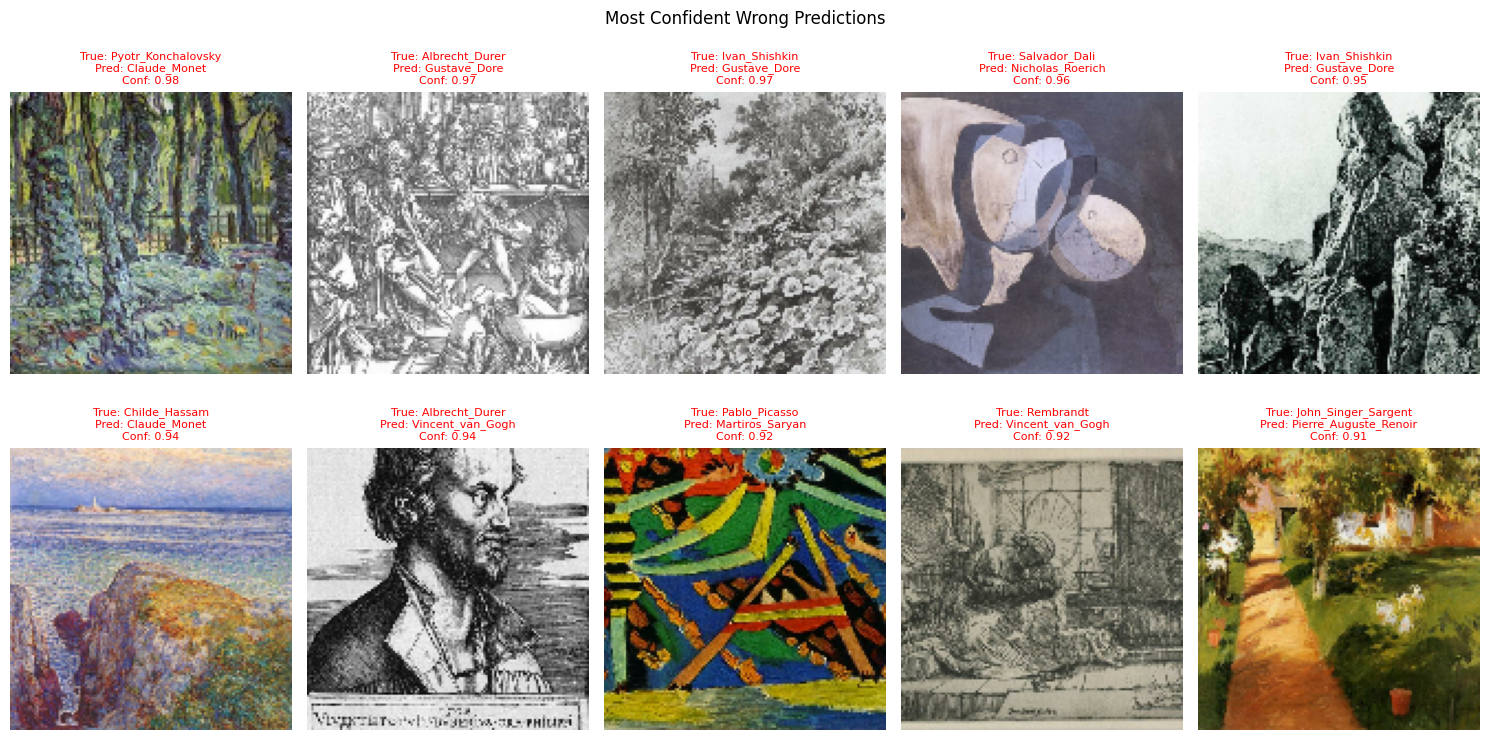

In [13]:
# Collect all misclassified images with their confidence
wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_df:
    probs        = model.predict(images, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    for i in range(len(true_classes)):
        if pred_classes[i] != true_classes[i]:
            wrong_imgs.append(images[i].numpy().astype('uint8'))
            wrong_true.append(true_classes[i])
            wrong_pred.append(pred_classes[i])
            wrong_conf.append(probs[i][pred_classes[i]])   # confidence of wrong prediction

# Sort by highest confidence wrong prediction (worst mistakes)
sorted_idx  = np.argsort(wrong_conf)[::-1]
n_show      = min(10, len(sorted_idx))

print(f'Total misclassified: {len(wrong_imgs)} / {len(y_true)} ({len(wrong_imgs)/len(y_true)*100:.1f}%)')

cols = 5
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, idx in enumerate(sorted_idx[:n_show]):
    axes[i].imshow(wrong_imgs[idx])
    axes[i].set_title(
        f'True: {class_names[wrong_true[idx]]}\nPred: {class_names[wrong_pred[idx]]}\nConf: {wrong_conf[idx]:.2f}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Most Confident Wrong Predictions', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'misclassified.png', dpi=150)
plt.show()

In [14]:
print(f"{'Class Name':<30} | {'Total Errors'}")
print("-" * 45)

for i, name in enumerate(class_names):
    # Total images in this class minus the ones on the diagonal (correct)
    total_in_class = cm[i].sum()
    correct_preds = cm[i, i]
    errors = total_in_class - correct_preds
    
    print(f"{name:<30} | {int(errors)}")

Class Name                     | Total Errors
---------------------------------------------
Albrecht_Durer                 | 48
Boris_Kustodiev                | 47
Camille_Pissarro               | 56
Childe_Hassam                  | 47
Claude_Monet                   | 42
Edgar_Degas                    | 46
Eugene_Boudin                  | 31
Gustave_Dore                   | 9
Ilya_Repin                     | 34
Ivan_Aivazovsky                | 22
Ivan_Shishkin                  | 28
John_Singer_Sargent            | 53
Marc_Chagall                   | 62
Martiros_Saryan                | 44
Nicholas_Roerich               | 60
Pablo_Picasso                  | 63
Paul_Cezanne                   | 38
Pierre_Auguste_Renoir          | 41
Pyotr_Konchalovsky             | 39
Raphael_Kirchner               | 26
Rembrandt                      | 32
Salvador_Dali                  | 47
Vincent_van_Gogh               | 63


/var/folders/57/tgwsfr6x1hx0tw49p3crhr400000gn/T/ipykernel_14972/1285065781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r')


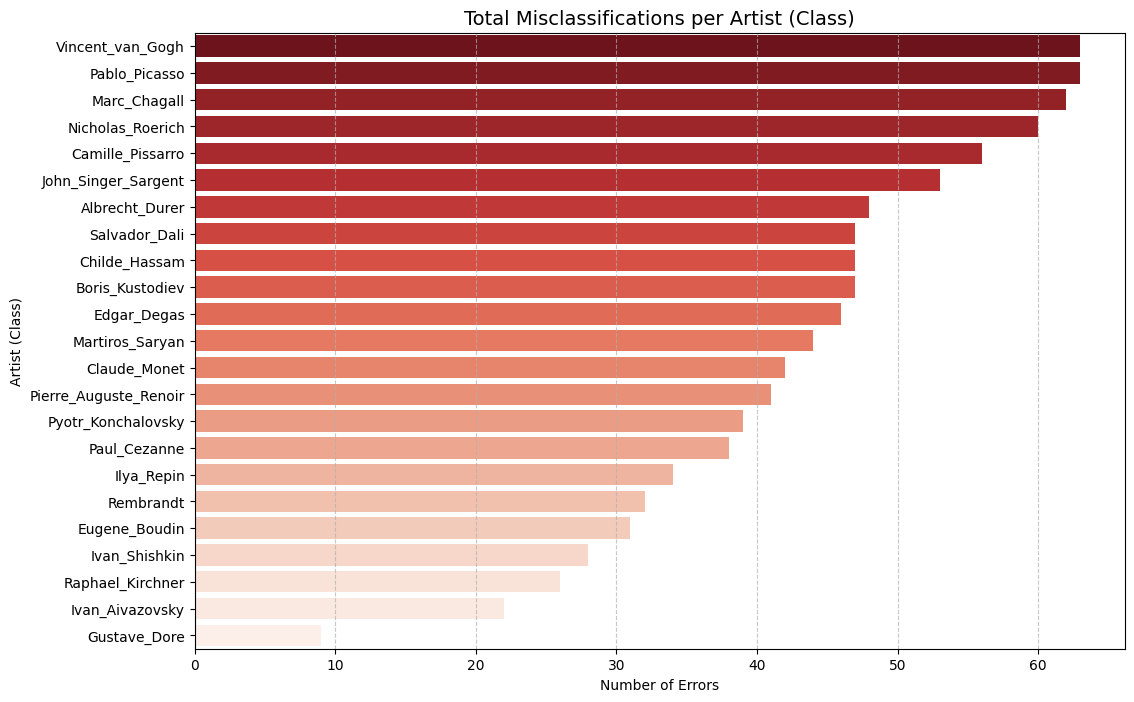

In [15]:
# Calculate error counts
error_counts = []
for i in range(len(class_names)):
    error_counts.append(cm[i].sum() - cm[i, i]) #cm is the confusion matrix

# Sort by error count
error_val_df = pd.DataFrame({'Artist': class_names, 'Errors': error_counts})
error_val_df = error_val_df.sort_values('Errors', ascending=False)

# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r') 

plt.title('Total Misclassifications per Artist (Class)', fontsize=14)
plt.xlabel('Number of Errors')
plt.ylabel('Artist (Class)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save for your project folder
plt.savefig(FIGURES_DIR / 'errors_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/57/tgwsfr6x1hx0tw49p3crhr400000gn/T/ipykernel_14972/575272202.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')


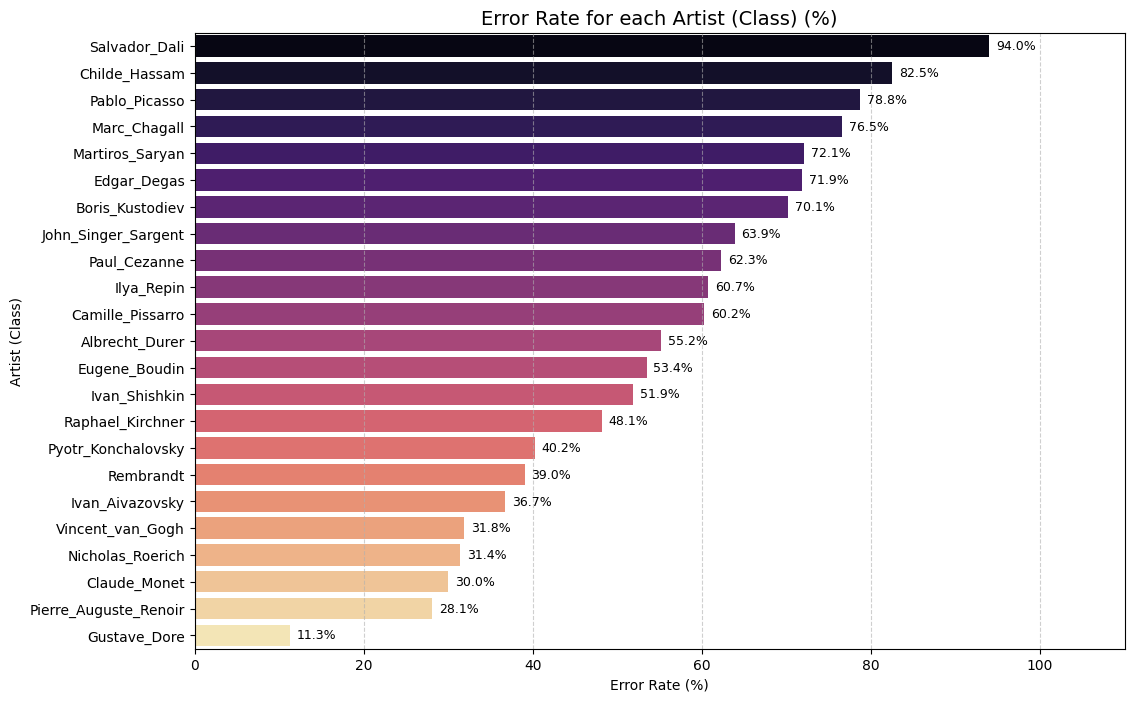

In [16]:
# percentage of errors for each class

per_class_error_pct = []

for i in range(len(class_names)):
    total_samples = cm[i].sum()
    if total_samples > 0:
        # (Total images - correct predictions / total images) * 100
        error_pct = (1 - (cm[i,i]) / total_samples) * 100
        per_class_error_pct.append(error_pct)
    else:
        per_class_error_pct.append(0)

# Save as DataFrame to ease the visualization

error_df = pd.DataFrame({
    'Artists (Class)': class_names,
    'Error %': per_class_error_pct
}).sort_values('Error %', ascending=False) # Order by the classes with the bigger % of error

# Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')

# To appear the % on the bars. 
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9)

plt.title('Error Rate for each Artist (Class) (%)', fontsize=14)
plt.xlabel('Error Rate (%)')
plt.ylabel('Artist (Class)')
plt.xlim(0, 110) # text
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig(FIGURES_DIR / 'error_percentage_by_class.png', dpi=150, bbox_inches='tight')
plt.show()